## Fine Tunning

«El objetivo de esta sección es demostrar cómo funciona el *fine-tuning* (ajuste fino). A nivel de configuración de código y estructura general, no difiere sustancialmente del preentrenamiento; las diferencias son sutiles, pero el principio operativo es el mismo.

Además, veremos algunos atajos prácticos para ahorrar tiempo. En lugar de entrenar un modelo aleatorio desde cero como hicimos antes, importaremos un modelo base de GPT ya preentrenado y lo ajustaremos utilizando el libro con el que hemos estado trabajando (*Los viajes de Gulliver*). La idea central no es construir una arquitectura totalmente nueva, sino tomar un modelo preexistente y adaptarlo para que desarrolle una preferencia estilística por generar texto que emule la prosa de esa obra».

---

In [1]:
# dato : la tasa del Learning Rate es mas pequeña para no sobreescribir la sintaxis

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

# Importar las clases necesarias de la librería Transformers de Hugging Face
# AutoModelForCausalLM permite cargar modelos preentrenados de lenguaje causal (como GPT-2)
# GPT2Tokenizer se encarga de tokenizar el texto específicamente para la arquitectura GPT-2
from transformers import AutoModelForCausalLM, GPT2Tokenizer

# Importar requests para realizar solicitudes HTTP (útil para descargar el texto del libro desde la web)
import requests

# Gráficos vectoriales
import matplotlib_inline.backend_inline

matplotlib_inline.backend_inline.set_matplotlib_formats('svg')

In [3]:
# Cargar el modelo preentrenado GPT-2 y su tokenizador
gpt2 = AutoModelForCausalLM.from_pretrained('gpt2')
tokenizer = GPT2Tokenizer.from_pretrained('gpt2')

# Hiperparámetros
seq_len = 256  # Longitud máxima de secuencia
batch_size = 16

# Usar GPU si está disponible
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  548MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

In [4]:
# Tokenizar el texto de Los viajes de Gulliver :)
text = requests.get(
    'https://www.gutenberg.org/cache/epub/829/pg829.txt'
).text

# La forma antigua:
gtTokens = torch.tensor(tokenizer.encode(text), dtype=torch.long)
print(gtTokens.shape)

# Una forma mejor ;)
gtTokens = tokenizer.encode(text, return_tensors='pt') #pt por pytorch
print(gtTokens.shape)

# Pero el resto del código está configurado para tensores sin dimensión (1D)
gtTokens = gtTokens[0] # estamos accediento a la 1 fila que es el unsqueeze del tensor
print(gtTokens.shape)

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (158340 > 1024). Running this sequence through the model will result in indexing errors


torch.Size([158340])
torch.Size([1, 158340])
torch.Size([158340])


In [5]:
# Tenemos 1, 158340 Pytorch tratara esta entrada como Lote x los tokens

In [6]:
# Encontrar los 100 tokens más frecuentes
uniq, counts = np.unique(gtTokens, return_counts=True) # devolver lso tokens unicos y retonar los conteos (TRUE)
freqidx = np.argsort(counts)[::-1] #slicing para invertir el orden
top100 = uniq[freqidx[:100]] # todos hasta los 100

for t in top100:
  print(
      f'Token {t:5} aparece {torch.sum(gtTokens==t):4} veces y es'  # Muestra el ID del token reservando 5 espacios de ancho para alinear la columna / # Cuenta las apariciones totales de ese token en el tensor reservando 4 espacios
      f' "{tokenizer.decode(t)}"'  # Traduce el ID numérico de vuelta a texto legible usando el tokenizador
)

Token    11 aparece 10060 veces y es ","
Token   198 aparece 9923 veces y es "
"
"
Token   262 aparece 5393 veces y es " the"
Token   286 aparece 3779 veces y es " of"
Token   290 aparece 3468 veces y es " and"
Token   284 aparece 3356 veces y es " to"
Token    13 aparece 3006 veces y es "."
Token   314 aparece 2657 veces y es " I"
Token   257 aparece 2431 veces y es " a"
Token   287 aparece 1900 veces y es " in"
Token    26 aparece 1562 veces y es ";"
Token   616 aparece 1474 veces y es " my"
Token   373 aparece 1199 veces y es " was"
Token   326 aparece 1061 veces y es " that"
Token   502 aparece  964 veces y es " me"
Token   351 aparece  941 veces y es " with"
Token   355 aparece  920 veces y es " as"
Token   465 aparece  823 veces y es " his"
Token   416 aparece  794 veces y es " by"
Token   329 aparece  776 veces y es " for"
Token   543 aparece  774 veces y es " which"
Token   447 aparece  734 veces y es "�"
Token   340 aparece  718 veces y es " it"
Token   307 aparece  698 veces 

Podemos ver que el token mas frecuente es el 11 que es "," aparece 10060, podemos apreciar que son tokens frecuentes que aparecen en cualquier libro ingles no es realmetne unico de los viajes de Gulliver, asi que no es sorprendente que tengamos un porcentaje de frecuencia mayor 40% antes de preentrenarlo con fine tunning

### Solo una pequeña demostración

In [7]:
# Mover el modelo a la GPU
gpt2 = gpt2.to(device)

In [8]:
# check out some text
prompt = 'I cannot believe that'
in2gpt = tokenizer.encode(prompt,return_tensors='pt').to(device)

In [9]:
output = gpt2.generate(in2gpt,max_length=100,pad_token_id=50256,do_sample=True).cpu()
print(tokenizer.decode(output[0]))

I cannot believe that she has the stamina or discipline or the financial or political talent or this individual has had to fight and lose his entire career. I am also stunned in my own heart that he has lost this election and is now in very deep denial of where his career is going," she told the Guardian. "I hope that this is not the catalyst for others in these communities to do what they can to stand up and to look at this on their own terms and to speak out."





### Cuantificar la frecuencia de los tokens frecuentes del libro GT en la salida de GPT

In [10]:
numreps = 10  # Número de repeticiones aleatorias
numtoks = 100  # Longitud de salida

# Tokens de inicio aleatorios
randstarts = torch.randint(tokenizer.vocab_size, (numreps, 1)).to(device)

# Generar texto con el modelo utilizando los tokens de inicio aleatorios
out = (
    gpt2.generate(  # Generar tokens de texto
        randstarts,  # Secuencia de entrada inicial (tokens de partida)
        max_length=numtoks + 1,  # Longitud máxima de la secuencia generada
        min_length=
        numtoks + 1,  # Longitud mínima (igualada para fijar el tamaño exacto)
        do_sample=
        True,  # Activar muestreo estocástico para generar respuestas variadas
        bad_words_ids=[
            tokenizer.encode(tokenizer.eos_token)
        ],  # Evitar que genere el token de fin de texto prematuramente
        pad_token_id=tokenizer.encode(tokenizer.eos_token)[
            0
        ],  # ID configurado para el relleno que no queden desiguales
    )
    .cpu()
)

print(out, '\n')

for o in out:
  print('\n*** Siguiente lote de salida:')
  print(tokenizer.decode(o))

[transformers] The attention mask is not set with a batched input, and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


tensor([[22836,    13,   785,  ...,   661, 11969,   674],
        [ 3332,    13,   198,  ...,   306,    14,  1157],
        [25229,   262,   976,  ...,   307,  4388,    11],
        ...,
        [ 6524,   278,   298,  ...,   739,   262,  7531],
        [16714,   198,   198,  ...,    40,   716,   257],
        [10951,   287,  7349,  ...,   326,   314,   423]]) 


*** Siguiente lote de salida:
 Trend.com. You will learn this on our journey to the ultimate goal we are ready to reach in our quest.

We don't pretend to be the news-gathering community. We just offer what we think works. We focus on creating and delivering news for you.

Thank you for sharing your passion for creating amazing content, we have a wonderful team for this job, and we plan to grow with you.

A special thanks to the very amazing and passionate people attending our

*** Siguiente lote de salida:
 sat.

"I think about my daughter as I walk into that building to my friend's funeral, and when I look back I realize that

---

### ¿Qué es el Token EOS y por qué lo bloqueamos aquí?

Imagina que estás chateando con ChatGPT y le haces una pregunta simple para que responda con un **"SÍ"** o un **"NO"**. GPT responde "Sí" y se detiene. Lo que ocurre internamente es que el modelo genera un token especial llamado **EOS** (*End of Sequence*, o fin de secuencia), el cual actúa como una señal de parada para indicarle que ya terminó de hablar.

* **Para un chatbot:** Esto es ideal, porque evita que el modelo siga escribiendo indefinidamente.
* **Para nuestro experimento actual:** **No lo queremos.** Como nuestro objetivo es cuantificar y forzar al modelo a generar exactamente una cantidad fija de fichas (tokens) de manera continua para este análisis, necesitamos evitar que se detenga antes de tiempo. Por eso utilizamos:
* `bad_words_ids`: Para prohibirle que utilice el token EOS.
* `pad_token_id`: Para definir cómo rellenar o manejar los espacios si fuera necesario, asegurando que el flujo de generación no se corte por accidente.

In [11]:
# esto nos dara 10 batches por 1 tensor

In [12]:
numreps
randstarts = torch.randint(tokenizer.vocab_size, (numreps, 1)).to(device)
print(randstarts.shape)

torch.Size([10, 1])


## Desglose de Parámetros Clave en la Generación de Texto

---

### 1. ¿Qué significa `torch.Size([10, 1])`?

Este tensor define la forma inicial con la que arranca el generador:

* **El `10` (`numreps`):** Representa el número de secuencias independientes que generamos en paralelo (actúa como un mini *batch size* de 10). En lugar de evaluar de uno en uno, el modelo procesa 10 intentos simultáneos.
* **El `1`:** Indica que cada una de esas 10 secuencias arranca con **un único token inicial aleatorio** (la semilla o punto de partida).

---

### 2. ¿Por qué se usa `max_length = numtoks + 1`?

* **El objetivo:** Queremos que el modelo genere exactamente **100 tokens nuevos** de texto (`numtoks = 100`).
* **El funcionamiento interno:** La función `.generate()` de Hugging Face mide la longitud total de la secuencia contando **tanto el texto de entrada como el generado**. Como nuestras secuencias de entrada (`randstarts`) ya tienen una longitud de **1 token**, si fijáramos el límite en 100, el modelo contaría ese token inicial y produciría solo 99 nuevos. Al sumar `+1`, garantizamos que el bloque resultante contenga el token de arranque más los 100 nuevos exactos.

---

### 3. El Token EOS y por qué lo bloqueamos en este experimento

Imagina que chateas con un modelo y le pides una respuesta corta de "SÍ" o "NO". El modelo responde y genera de manera automática un token especial llamado **EOS** (*End of Sequence*, fin de secuencia), que actúa como señal para dejar de generar texto:

* **Para un chatbot:** Es ideal, ya que evita que el modelo siga escribiendo indefinidamente.
* **Para nuestro experimento:** **No lo queremos**. Como el objetivo es cuantificar de forma continua la aparición de ciertos tokens a lo largo de una longitud fija, necesitamos evitar que el modelo se detenga antes de tiempo. Para ello utilizamos:
* `bad_words_ids`: Para prohibirle explícitamente que utilice el token EOS.
* `pad_token_id`: Para configurar el identificador de relleno y asegurar que el flujo de generación no sufra interrupciones accidentales.

In [13]:
# por que no tengo un 1000 en vez de  1000 en 10 secuencias?

## Coherencia y Longitud: Modelos Base vs. Modelos Comerciales

---

### 1. El problema de la deriva en modelos base (*scratch / pretrained*)

Cuando trabajas con un modelo base entrenado únicamente con predicción del siguiente token (*next-token prediction*):

* **Propagación de errores:** Si el modelo comete un pequeño desliz en el token 50, ese error pasa a formar parte del contexto para predecir el token 51. A medida que avanza la generación, los errores se acumulan (*exposure bias*).

* **Degradación rápida:** Sin un mecanismo de alineación, la salida tiende a entrar en bucles repetitivos, perder el hilo conceptual o volverse completamente incoherente ("estratosférica),  a medida que aumenta la longitud.
* **Estrategia de análisis:** Por eso, para experimentos de investigación, benchmarking o análisis interno de tensores, es mucho más útil evaluar múltiples secuencias cortas y controladas que arriesgarse a largas tiradas de texto basura.

### 2. La evolución en los chatbots comerciales modernos

Los asistentes comerciales que usamos hoy en día (como ChatGPT, Claude, etc.) superan esta limitación gracias a fases de entrenamiento avanzadas posteriores al preentrenamiento:

* **SFT (*Supervised Fine-Tuning*):** Se les enseña mediante ejemplos de alta calidad a estructurar respuestas largas y lógicas.
* **RLHF / DPO (*Reinforcement Learning from Human Feedback / Direct Preference Optimization*):** Se les penaliza explícitamente cuando divagan o pierden la coherencia a mitad de una explicación extensa.

Esta es la razón exacta por la cual un modelo comercial puede mantener una hilación impecable a lo largo de miles de tokens, mientras que un modelo base entrenado desde cero colapsa rápidamente si se le exige autonomía a largo plazo.

In [14]:
# Calcular y reportar el porcentaje de aparición de los tokens más comunes
percentFreqTokens_pre = np.mean(
    100
    * np.isin(
        out[:, 1:], top100
    ).flatten()  # 1. out[:, 1:] omite el token inicial y toma solo los generados
    # 2. np.isin comprueba si cada token pertenece a la lista 'top100' (devuelve True/False)
    # 3. .flatten() aplana la matriz bidimensional en un vector unidimensional
    # 4. 100 * ... convierte los booleanos en 100 y 0 para calcular el porcentaje medio
)

# Imprimir el resultado traducido y formateado en pantalla
print(
    f"Los tokens comunes de Los viajes de Gulliver aparecieron en el"
    f" {percentFreqTokens_pre}% de los nuevos tokens."
)

Los tokens comunes de Los viajes de Gulliver aparecieron en el 43.7% de los nuevos tokens.


## Fine tunear el Modelo

In [15]:
# Crear la función de optimización (nota la tasa de aprendizaje pequeña)
optimizer = torch.optim.AdamW(gpt2.parameters(), lr=5e-5, weight_decay=0.01)

# Nota: no necesitamos definir una función de pérdida aquí,
# porque se calcula internamente en el modelo (¡gracias Hugging Face :D!)

In [16]:
# Definir el número total de muestras o pasos de entrenamiento
num_samples = 1234

# Inicializar un vector de ceros para almacenar la pérdida en cada muestra
train_loss = np.zeros(num_samples)

# Bucle principal de entrenamiento iterando sobre cada muestra
for sampli in range(num_samples):

  # Obtener un lote aleatorio de índices dentro del texto de entrenamiento
  ix = torch.randint(len(gtTokens) - seq_len, size=(batch_size,))
  X = gtTokens[ix[:, None] + torch.arange(seq_len)]

  # Mover los datos de entrada al dispositivo configurado (GPU o CPU)
  X = X.to(device)

  # Limpiar los gradientes acumulados en el paso anterior
  gpt2.zero_grad()

  # Propagación hacia adelante (Forward pass):
  # Hugging Face desplaza internamente los tokens de X para usarlos como objetivo (y)
  outputs = gpt2(X, labels=X)
  loss = outputs.loss

  # Retropropagación (Backpropagation) para calcular los nuevos gradientes
  loss.backward()

  # Actualizar los pesos del modelo usando el optimizador
  optimizer.step()

  # Almacenar el valor escalar de la pérdida de esta muestra específica
  train_loss[sampli] = loss.item()

  # Actualizar y mostrar el progreso del entrenamiento en pantalla cada 77 iteraciones
  if sampli % 77 == 0:
    print(
        f"Muestra {sampli:4}/{num_samples}, pérdida de entrenamiento:"
        f" {train_loss[sampli]:.4f}"
    )

[transformers] `loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


Muestra    0/1234, pérdida de entrenamiento: 5.4038
Muestra   77/1234, pérdida de entrenamiento: 2.8174
Muestra  154/1234, pérdida de entrenamiento: 2.5880
Muestra  231/1234, pérdida de entrenamiento: 2.6984
Muestra  308/1234, pérdida de entrenamiento: 1.9849
Muestra  385/1234, pérdida de entrenamiento: 1.7350
Muestra  462/1234, pérdida de entrenamiento: 1.5471
Muestra  539/1234, pérdida de entrenamiento: 1.1071
Muestra  616/1234, pérdida de entrenamiento: 0.9835
Muestra  693/1234, pérdida de entrenamiento: 0.6549
Muestra  770/1234, pérdida de entrenamiento: 0.5627
Muestra  847/1234, pérdida de entrenamiento: 0.3448
Muestra  924/1234, pérdida de entrenamiento: 0.3687
Muestra 1001/1234, pérdida de entrenamiento: 0.2921
Muestra 1078/1234, pérdida de entrenamiento: 0.2547
Muestra 1155/1234, pérdida de entrenamiento: 0.2326
Muestra 1232/1234, pérdida de entrenamiento: 0.2323


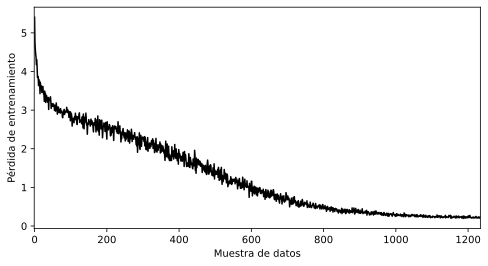

In [17]:
# Configurar el tamaño y las proporciones de la figura para la gráfica
plt.figure(figsize=(8, 4))

# Dibujar la curva de la pérdida de entrenamiento ('k' representa el color negro)
plt.plot(train_loss, 'k', markersize=8)

# Configurar las etiquetas de los ejes y los límites del eje horizontal (X)
plt.gca().set(
    xlabel="Muestra de datos",
    ylabel="Pérdida de entrenamiento",
    xlim=[-1, num_samples],
)

# Mostrar la gráfica generada en pantalla
plt.show()

---

Ahora, en la fase de evaluación, el texto generado refleja el estilo de *Los viajes de Gulliver*. Adopta su sintaxis, coherencia y nivel de relevancia, dejando atrás los párrafos largos y convencionales para imitar la cadencia y el formato de lectura característicos de la obra original.

---

In [18]:
# Evaluación cualitativa del modelo
prompt = "I cannot believe that"
in2gpt = tokenizer.encode(prompt, return_tensors="pt").to(device)

# Generar texto a partir del prompt (máximo 100 tokens, especificando el token de relleno)
output = gpt2.generate(in2gpt, max_length=100, pad_token_id=50256)

# Decodificar los tokens resultantes de vuelta a texto legible e imprimirlos
print(tokenizer.decode(output[0]))

I cannot believe that I shall ever get the liberty I are accustomed
to from this monstrous and dangerous prospect. But I was assured by
his honour, that those execrable authorities which I was
relieved with great diligence in this affair, would have been much better
armed by you, or by the ages; that the great officers in
my opinion would have gladly taken a dozen years to find their
true colours manifest; and that millions of their subjects


# Calcular el porcentaje de tokens GT generados

In [19]:
# Tokens de inicio aleatorios (genera tantas filas como 'numreps' y 1 columna)
randstarts = torch.randint(tokenizer.vocab_size, (numreps, 1)).to(device)

# Generar datos / texto utilizando el modelo
out = gpt2.generate(
    randstarts,
    max_length=numtoks + 1,
    min_length=numtoks + 1,
    do_sample=True,  # Habilitar muestreo estocástico en lugar de búsqueda determinista
    bad_words_ids=[
        tokenizer.encode(tokenizer.eos_token)
    ],  # Evitar que genere el token de fin de secuencia prematuramente
    pad_token_id=tokenizer.encode(tokenizer.eos_token)[
        0
    ],  # Definir el ID del token de relleno (padding)
).cpu()

# Iterar sobre cada secuencia generada en la salida para decodificarla e imprimirla
for o in out:
  print("\n*** Siguiente lote de salida:")
  print(tokenizer.decode(o))


*** Siguiente lote de salida:
 Developers, in addition to being persons of high distinction and great abilities, they
were bound to act in a manner proportionably with the character
I had chosen for myself: that I intended to carry on the war with
England, because I found it was too terrible a punishment; that I could
perhaps serve my master in his vice, and reduce the whole race of
innocent human race to more wretched conditions; that I reflected, since I
was forced to

*** Siguiente lote de salida:
 graphic
with a little more humour, and engage the reader upon several occasions to
gather this intelligence, which you are welcome to supply him with.

“There are two others abroad, who seem to be confined to a particular part of
the coast, but never walk on the land, except in very curiosity and curiosity
to see those prodigious animals in the sea, which must be the most
fondly excrement they have ever

*** Siguiente lote de salida:
 paraly
perjury suffered by one of the servants. The m

In [20]:
# Calcular y reportar el porcentaje de uso de tokens frecuentes tras la generación
percentFreqTokens_pst = np.mean(
    100 * np.isin(out[:, 1:], top100).flatten()
)

print(
    f"El uso de tokens comunes de GT pasó de {percentFreqTokens_pre:.2f}% a"
    f" {percentFreqTokens_pst:.2f}% después del ajuste fino (fine-tuning)."
)

El uso de tokens comunes de GT pasó de 43.70% a 60.00% después del ajuste fino (fine-tuning).


---

### Conclusión: ¿Es bueno o malo que el porcentaje de tokens sea muy alto?

Cuando estudiamos optimización con descenso de gradiente (Gradient Descent), aprendemos que una pérdida de prueba (*test loss*) baja es ideal, y que llegar a cero suele indicar un rendimiento perfecto. Sin embargo, **¿aplica esta misma lógica en un modelo de lenguaje?**

Si la pérdida cae drásticamente hasta cero, significa que el modelo ha memorizado los datos de entrenamiento al extremo. Esto conlleva un grave riesgo de **sobreajuste (*overfitting*)**, lo que provoca que el modelo pierda la capacidad de generalizar y de aprender a generar secuencias de tokens novedosas.

Lo que realmente buscamos en un LLM no es una memorización fotográfica y perfecta del texto de entrenamiento, sino **creatividad controlada, coherencia sintáctica, lógica y utilidad práctica** en el contenido que genera.

---